# Import:

In [151]:
from sklearn.exceptions import DataConversionWarning
import warnings

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DataConversionWarning)

In [152]:
import pandas as pd
import numpy as np

data = pd.read_csv("/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /Data Set/vcb_Training_Data.csv")
"""
data = data.set_index("Date")
"""
data.rename(columns={'Unnamed: 0': 'time'}, inplace=True)
data.set_index("time", inplace=True)

df = data.copy()

training_data = df.loc[:, ~df.columns.isin(["target", "strength target", "regression target"])].copy()
target= df.loc[:, ["target"]].copy()

display(training_data.shape, target.shape)
display(data)

def data_split(split_percentage, df):

    assert 0 < split_percentage < 1, "split_percentage must be a float between 0 and 1 (exclusive)"

    split_index = int(len(df) * split_percentage)

    train_df = df.iloc[:split_index].copy()
    test_df = df.iloc[split_index:].copy()

    return train_df, test_df

X, Valid_set = data_split(split_percentage=0.8, df=training_data.reset_index(drop=True))
y, Valid_result = target.reset_index(drop=True).loc[X.index], target.reset_index(drop=True).loc[Valid_set.index]

(3214, 108)

(3214, 1)

,open,high,low,close,volume,vnindex,vn30,hnx,gold,oil,...,momentum_ppo_signal,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,momentum_kama,others_dr,others_dlr,others_cr,target
time,,,,,,,,,,,,,,,,,,,,,
2012-04-23,7.82,7.91,7.79,7.82,404510.0,465.17,533.60,77.81,1631.900024,118.709999,...,3.463147,1.301056,18.878575,16.927344,1.951231,6.833936,0.704225,0.701757,41.261261,0.0
2012-04-24,7.84,7.84,7.70,7.77,643880.0,465.65,534.89,78.57,1643.000000,118.160004,...,3.791061,1.311654,16.605561,16.862987,-0.257426,6.836437,-1.398601,-1.408474,40.900901,0.0
2012-04-25,7.89,7.89,7.72,7.77,560280.0,472.87,542.78,79.55,1641.400024,119.120003,...,4.173091,1.528121,22.493083,17.989006,4.504076,6.837802,-0.283688,-0.284091,40.000000,0.0
2012-04-26,7.84,7.84,7.74,7.74,507420.0,470.21,538.10,78.74,1659.599976,119.919998,...,4.470873,1.191129,22.381355,18.867476,3.513879,6.945705,-3.413940,-3.473576,40.000000,0.0
2012-04-27,7.86,7.96,7.77,7.86,587740.0,473.77,541.20,79.86,1664.000000,119.830002,...,4.688938,0.872261,20.622134,19.218408,1.403726,7.046370,1.767305,1.751870,39.459459,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-28,69.50,70.60,68.70,69.00,8799400.0,1680.86,1861.20,276.63,3431.800049,68.620003,...,0.605956,0.882843,27.378349,15.621999,11.756349,62.478224,-1.149425,-1.156082,1145.045045,0.0
2025-08-29,69.20,70.10,68.50,68.60,14696100.0,1682.21,1865.38,279.98,3473.699951,68.120003,...,0.864885,1.035717,29.479506,18.393501,11.086005,62.726694,0.000000,0.000000,1143.243243,0.0
2025-09-03,68.80,68.80,67.00,67.00,14216900.0,1681.30,1859.59,282.70,3593.199951,67.599998,...,1.123181,1.033182,24.856416,19.686084,5.170332,62.933113,1.495017,1.483951,1136.036036,1.0


# Implementation:

In [153]:
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
from scipy.stats import entropy, chi2_contingency, f_oneway
from sklearn.preprocessing import StandardScaler
from itertools import combinations

# -----------------------------
# Helper functions
# -----------------------------
def js_divergence(p, q, eps=1e-12):
    p = np.array(p) + eps
    q = np.array(q) + eps
    m = 0.5 * (p + q)
    return 0.5 * (entropy(p, m) + entropy(q, m))

def regime_homogeneity(feature, labels):
    """Intra-regime variance"""
    return np.mean([np.var(feature[labels == r]) for r in np.unique(labels)])

def regime_heterogeneity(feature, labels):
    """Inter-regime JS divergence using histogram approximation"""
    regimes = np.unique(labels)
    js_scores = []
    for i in range(len(regimes)):
        for j in range(i + 1, len(regimes)):
            p = np.histogram(feature[labels == regimes[i]], bins=20, density=True)[0]
            q = np.histogram(feature[labels == regimes[j]], bins=20, density=True)[0]
            js_scores.append(js_divergence(p, q))
    return np.mean(js_scores)

def target_alignment(feature, labels, target):
    """Chi-square for categorical target or ANOVA for continuous target"""
    if len(np.unique(target)) <= 10:  # categorical
        contingency = pd.crosstab(target, labels)
        chi2, p, _, _ = chi2_contingency(contingency)
        return chi2
    else:  # continuous
        f_stat, p = f_oneway(*[target[labels == r] for r in np.unique(labels)])
        return f_stat

# -----------------------------
# Fit GMM for a single feature
# -----------------------------
def fit_gmm_feature(feature, n_components=2, random_state=42):
    feature = feature.reshape(-1,1)
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=random_state)
    gmm.fit(feature)
    labels = gmm.predict(feature)
    return labels, gmm

# -----------------------------
# Feature scoring function
# -----------------------------
def score_features(X, target, n_components=2):
    """
    X: pd.DataFrame or np.array, shape (n_samples, n_features)
    target: target vector
    """

    df = data.corrwith(data["target"])
    pos_col = df[df > 0].sort_values(ascending=False).index.to_list()[1:]

    X = X.loc[:, pos_col]
    X1 = np.array(X.copy())

    n_methods = len(X.columns)

    scores = []
    for r in range(1, n_methods + 1):
        for combo in combinations(range(n_methods), r):

            feature = X1[:, list(combo)]
            labels, _ = fit_gmm_feature(feature, n_components=n_components)
            intra_var = regime_homogeneity(feature, labels)
            inter_js = regime_heterogeneity(feature, labels)
            alignment = target_alignment(feature, labels, target)
            score = (inter_js / (intra_var + 1e-6)) * alignment
            scores.append({
                "feature_index": X.columns[list(combo)],
                "intra_var": intra_var,
                "inter_js": inter_js,
                "alignment": alignment,
                "score": score
            })
    return pd.DataFrame(scores).sort_values("score", ascending=False)

In [154]:
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
from scipy.stats import entropy, chi2_contingency, f_oneway # Added f_oneway
from sklearn.preprocessing import StandardScaler
from itertools import combinations

# -----------------------------
# Step 0: Helper functions
# -----------------------------
def js_divergence(p, q, eps=1e-12):
    """Compute Jensen-Shannon divergence between two probability distributions"""
    p = np.array(p) + eps
    q = np.array(q) + eps
    m = 0.5 * (p + q)
    return 0.5 * (entropy(p, m) + entropy(q, m))

def regime_homogeneity(data, labels):
    """Compute intra-regime variance for each regime"""
    # Ensure data and labels have compatible dimensions, truncate labels if mismatched
    if data.shape[0] != labels.shape[0]:
        print(f"Warning: Data and labels have different sizes in regime_homogeneity. Data size: {data.shape[0]}, Labels size: {labels.shape[0]}. Truncating labels.")
        labels = labels[:data.shape[0]] # Truncate labels to match data size

    var_list = []
    for regime in np.unique(labels):
        # Ensure there are samples for the current regime
        if np.sum(labels == regime) > 0:
            var_list.append(np.mean(np.var(data[labels == regime], axis=0)))
    # Handle case where no regimes have samples
    if not var_list:
        return 0.0
    return np.mean(var_list)

def regime_heterogeneity(data, labels):
    """Compute inter-regime JS divergence for each feature"""
    # Ensure data and labels have compatible dimensions, truncate labels if mismatched
    if data.shape[0] != labels.shape[0]:
        print(f"Warning: Data and labels have different sizes in regime_heterogeneity. Data size: {data.shape[0]}, Labels size: {labels.shape[0]}. Truncating labels.")
        labels = labels[:data.shape[0]] # Truncate labels to match data size

    regimes = np.unique(labels)
    js_scores = []
    # Ensure there is more than one regime with samples
    if len(regimes) < 2:
        return 0.0

    for i in range(len(regimes)):
        for j in range(i + 1, len(regimes)):
            # Ensure both regimes have samples
            if np.sum(labels == regimes[i]) > 0 and np.sum(labels == regimes[j]) > 0:
                # Handle single feature case for histogram
                if data.ndim == 1 or data.shape[1] == 1:
                     p = np.histogram(data[labels == regimes[i]], bins=20, density=True)[0]
                     q = np.histogram(data[labels == regimes[j]], bins=20, density=True)[0]
                     js_scores.append(js_divergence(p, q))
                else:
                    # For multiple features, compute JS for each feature and average
                    feature_js_scores = []
                    for k in range(data.shape[1]):
                        p = np.histogram(data[labels == regimes[i], k], bins=20, density=True)[0]
                        q = np.histogram(data[labels == regimes[j], k], bins=20, density=True)[0]
                        feature_js_scores.append(js_divergence(p, q))
                    js_scores.append(np.mean(feature_js_scores))

    # Handle case where no pairwise comparisons were made
    if not js_scores:
        return 0.0
    return np.mean(js_scores)


def target_alignment(feature, labels, target):
    """Chi-square for categorical target or ANOVA for continuous target"""
    # Ensure feature, labels and target have compatible dimensions
    if feature.shape[0] != labels.shape[0] or feature.shape[0] != target.shape[0]:
         raise ValueError(f"Feature, labels and target must have the same number of samples. Got {feature.shape[0]}, {labels.shape[0]}, and {target.shape[0]}.")

    if len(np.unique(target)) <= 10:  # categorical
        # Ensure there are samples for each combination of target and label
        if len(np.unique(labels)) > 0 and len(np.unique(target)) > 0:
            contingency = pd.crosstab(target, labels)
            # Ensure contingency table is not empty
            if not contingency.empty:
                chi2, p, _, _ = chi2_contingency(contingency)
                return chi2
            else:
                return 0.0
        else:
            return 0.0
    else:  # continuous
        # Ensure there are samples for each regime
        groups = [target[labels == r] for r in np.unique(labels) if np.sum(labels == r) > 0]
        if len(groups) > 1:
            f_stat, p = f_oneway(*groups)
            return f_stat
        else:
            return 0.0

# -----------------------------
# Step 1: Fit GMM for candidate regimes
# -----------------------------
def fit_gmm_feature(feature, n_components=2, random_state=42):
    """
    feature: np.array or pd.DataFrame of features (rows=samples, cols=features)
    n_components: number of regimes
    """
    # Ensure feature is a 2D array
    if feature.ndim == 1:
        feature = feature.reshape(-1, 1)
    elif feature.ndim > 2:
         raise ValueError(f"Feature must be 1D or 2D, got {feature.ndim} dimensions.")

    # Ensure there are enough samples for the number of components
    if feature.shape[0] < n_components:
        # Return dummy labels or raise an error if not enough samples
        return np.zeros(feature.shape[0], dtype=int), None

    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=random_state)
    gmm.fit(feature)
    labels = gmm.predict(feature)
    return labels, gmm

# -----------------------------
# Step 2: Evaluate regimes
# -----------------------------
def evaluate_regimes(X, labels, target=None):
    """
    X: features (np.array or pd.DataFrame)
    labels: regime labels (np.array or pd.Series)
    target: optional target vector for separability (np.array or pd.Series)
    """
    # Ensure inputs have the same number of samples
    if X.shape[0] != labels.shape[0]:
        raise ValueError(f"X and labels must have the same number of samples. Got {X.shape[0]} and {labels.shape[0]}.")
    if target is not None and X.shape[0] != target.shape[0]:
         raise ValueError(f"X and target must have the same number of samples. Got {X.shape[0]} and {target.shape[0]}.")

    # Convert X to numpy array if it's a DataFrame for consistent indexing
    if isinstance(X, pd.DataFrame):
        X_np = X.values
    else:
        X_np = X

    intra_var = regime_homogeneity(X_np, labels)
    inter_js = regime_heterogeneity(X_np, labels)
    if target is not None:
        alignment = target_alignment(X_np, labels, target) # Use target_alignment with X_np
    else:
        alignment = 0.0
    return {"intra_variance": intra_var, "inter_js": inter_js, "alignment": alignment}

# -----------------------------
# Step 3: Full regime selection workflow
# -----------------------------
def score_features(X, target, n_components=2):
    """
    X: pd.DataFrame or np.array, shape (n_samples, n_features)
    target: target vector
    """

    # Ensure X is a pandas DataFrame for correlation calculation
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)

    df_corr = X.copy()
    df_corr["target"] = target # Add target for correlation calculation

    df = df_corr.corrwith(df_corr["target"])
    pos_col = df[df > 0].sort_values(ascending=False).index.to_list()[1:]

    # Ensure there are positive correlated columns
    if not pos_col:
        return pd.DataFrame() # Return empty DataFrame if no features have positive correlation

    X_filtered = X.loc[:, pos_col].copy()
    X1 = np.array(X_filtered.copy())

    n_methods = X1.shape[1]

    scores = []
    for r in range(1, n_methods + 1):
        for combo in combinations(range(n_methods), r):

            feature = X1[:, list(combo)]
            labels, _ = fit_gmm_feature(feature, n_components=n_components)

            # Ensure labels are generated before calculating scores
            if labels is not None:
                intra_var = regime_homogeneity(feature, labels)
                inter_js = regime_heterogeneity(feature, labels)
                alignment = target_alignment(feature, labels, target)
                # Avoid division by zero
                score = (inter_js / (intra_var + 1e-6)) * alignment if (intra_var + 1e-6) != 0 else 0

                scores.append({
                    "feature_index": X_filtered.columns[list(combo)].tolist(), # Store column names
                    "intra_var": intra_var,
                    "inter_js": inter_js,
                    "alignment": alignment,
                    "score": score
                })
    return pd.DataFrame(scores).sort_values("score", ascending=False)


def distribution_based_regime_selection(X, target=None, n_components_list=[2,3,4], feature_set=None):
    best_score = -np.inf
    best_labels = None
    best_n = None
    results = []
    labels_series = {}

    for n in n_components_list:
        '''
        # Score features
        feature_scores = score_features(X.copy(), target.copy(), n_components=n) # Use target directly

        # Ensure feature_scores is not empty
        if feature_scores.empty:
            print(f"No features with positive correlation found for n_components={n}.")
            continue

        # Select the best feature set
        best_feature_row = feature_scores.iloc[0]
        feature_set = best_feature_row["feature_index"]
        '''

        # Ensure feature_set is a list of strings
        if isinstance(feature_set, str):
            feature_set = [feature_set]
        elif isinstance(feature_set, pd.core.indexes.base.Index):
             feature_set = feature_set.tolist()

        # Ensure X is a DataFrame for column selection
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)

        # Fit GMM on the selected feature set
        labels, gmm = fit_gmm_feature(X[feature_set], n_components=n) # Corrected function call

        # Ensure labels are generated before evaluating regimes
        if labels is not None:

            labels_series[f"n_components_ {str(n)}"] = labels

            metrics = evaluate_regimes(X, labels, target)
            # Simple scoring: maximize inter_js / intra_variance
            score = metrics['inter_js'] / (metrics['intra_variance'] + 1e-6)
            metrics.update({"n_components": n, "score": score})
            results.append(metrics)
            if score > best_score:
                best_score = score
                best_labels = labels
                best_n = n

    return labels_series, best_labels, best_n, pd.DataFrame(results)

# -----------------------------
# Example usage
# -----------------------------

X1 = X.copy()
target = y.copy().values.T[0]
#feature_set = results[0][0]
feature_set = ["log_return"]
n_components_list=[i for i in range(2, 5)]

# Run workflow
labels_series, labels, best_n, metrics_df = distribution_based_regime_selection(X1, target, n_components_list, feature_set)

print("Best number of regimes:")
display(pd.DataFrame(labels_series).head())
print(metrics_df)

Best number of regimes:


,n_components_ 2,n_components_ 3,n_components_ 4
0,0,1,1
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,1


   intra_variance  inter_js  alignment  n_components         score
0    1.109752e+14  0.028656   0.257509             2  2.582174e-16
1    1.110419e+14  0.045966  10.970952             3  4.139517e-16
2    1.079689e+14  0.051720  17.493120             4  4.790240e-16


## File Saving:

In [134]:
import joblib

# Save model and threshold together
package = {
    "model": GaussianMixture(n_components=best_n, covariance_type='full', random_state=42),
    "array": feature_set[0]
}
    
joblib.dump(package, '/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /ML models/prediction dataset/Classification/gmm_model_with_threshold.pkl')

['/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /ML models/prediction dataset/Classification/gmm_model_with_threshold.pkl']

# Optimization plots:

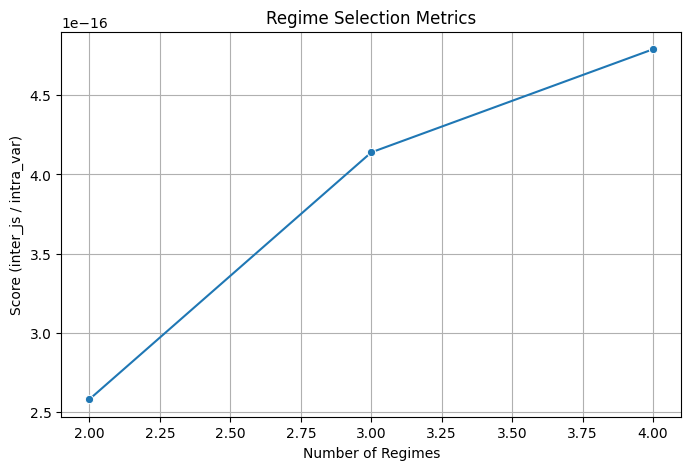

In [155]:
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. Plot regime metrics
# -----------------------------
def plot_regime_metrics(metrics_df):
    fig, ax1 = plt.subplots(figsize=(8,5))

    # Score vs n_components
    sns.lineplot(x='n_components', y='score', data=metrics_df, marker='o', ax=ax1)
    ax1.set_xlabel("Number of Regimes")
    ax1.set_ylabel("Score (inter_js / intra_var)")
    ax1.set_title("Regime Selection Metrics")
    ax1.grid(True)
    plt.show()

# -----------------------------
# 2. Plot regimes on features
# -----------------------------
def plot_regimes_2d(X, labels, target=None):
    plt.figure(figsize=(8,6))
    X = np.array(X)
    n_regimes = len(np.unique(labels))
    palette = sns.color_palette("tab10", n_regimes)

    for i, regime in enumerate(np.unique(labels)):
        idx = labels == regime
        plt.scatter(X[idx, 0], X[idx, 1], label=f"Regime {regime}", alpha=0.6, color=palette[i])

    if target is not None:
        # Overlay target separation (optional)
        for t in np.unique(target):
            plt.scatter([], [], label=f"Target {t}", marker="x")

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Data Points Colored by Regimes")
    plt.legend()
    plt.grid(True)
    plt.show()

# -----------------------------
# Example usage after running workflow
# -----------------------------
plot_regime_metrics(metrics_df)


# Distribution plots:

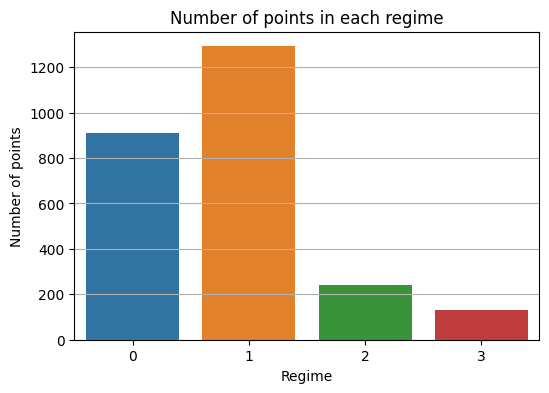

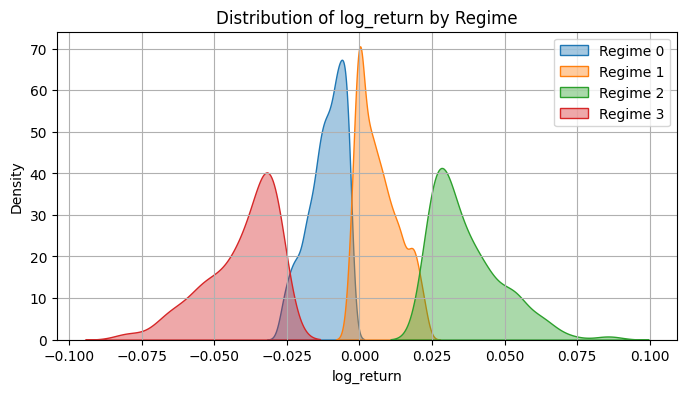

In [156]:
# -----------------------------
# 1. Bar plot: regime counts
# -----------------------------
def plot_regime_counts(labels):
    unique, counts = np.unique(labels, return_counts=True)
    plt.figure(figsize=(6,4))
    sns.barplot(x=unique, y=counts, palette="tab10")
    plt.xlabel("Regime")
    plt.ylabel("Number of points")
    plt.title("Number of points in each regime")
    plt.grid(axis='y')
    plt.show()

# -----------------------------
# 2. Histogram / density of features per regime
# -----------------------------
def plot_feature_distribution_per_regime(X, labels, feature_names=None):
    # Convert X to numpy array for easier indexing if it's a pandas DataFrame
    if isinstance(X, pd.DataFrame):
        X_np = X.values
    else:
        X_np = X

    n_features = X_np.shape[1]
    if feature_names is None:
        feature_names = [f"Feature {i}" for i in range(n_features)]

    for i, name in enumerate(feature_names):
        plt.figure(figsize=(8,4))
        for regime in np.unique(labels):
            # Use numpy indexing on the converted numpy array
            sns.kdeplot(X_np[labels == regime, i], label=f"Regime {regime}", fill=True, alpha=0.4)
        plt.title(f"Distribution of {name} by Regime")
        plt.xlabel(name)
        plt.ylabel("Density")
        plt.legend()
        plt.grid(True)
        plt.show()

# -----------------------------
# Example usage
# -----------------------------

plot_regime_counts(labels)
plot_feature_distribution_per_regime(X[feature_set], labels, feature_names=X[feature_set].columns)

# Series plots:

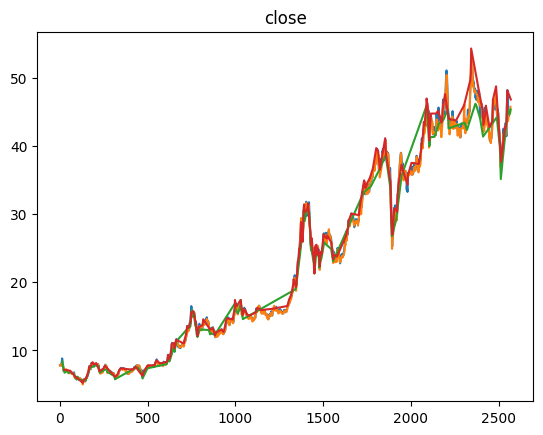

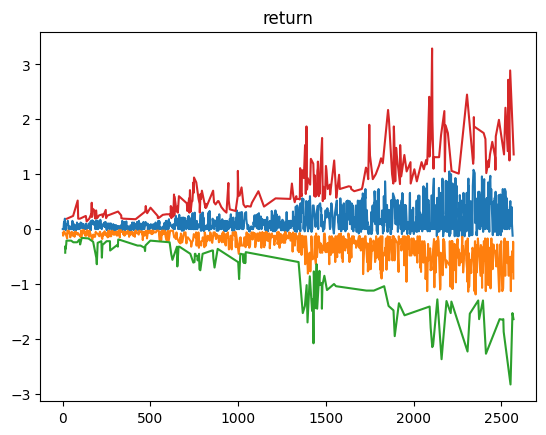

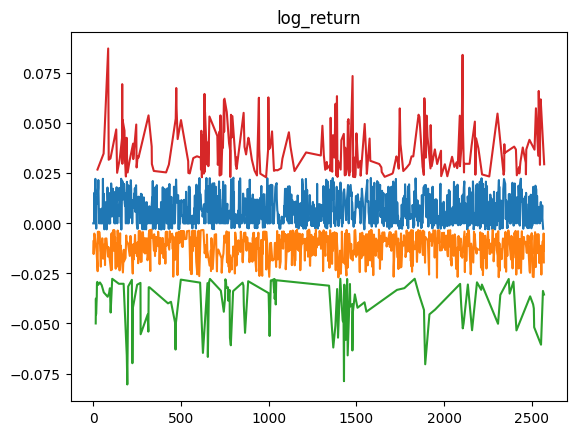

In [157]:
X1 = X.loc[:, ["close", "return", "log_return"]]
X1["regimes"] = labels

for array in ["close", "return", "log_return"]:
    for i in X1.regimes.unique():
        plt.plot(X1.loc[ X1.regimes == i, [array]])
    plt.title(array)
    plt.show()

# Test set prediction 1:

## ML models import

In [160]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
import joblib

model_paths = ["knn_model_with_regimes.pkl", "logr_model_with_regimes.pkl", "rf_model_with_regimes.pkl", "xgb_model_with_regimes.pkl"]
model_names = ["KNNs", "LogR", "RF", "XGB"]
model_infor = {}

for name, path in zip(model_names, model_paths):
    model_infor[name] = joblib.load(f"/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /ML models/prediction dataset/Classification/{path}")
    
for key, infor in model_infor.items():
    print(f"{key}: {display(infor['model'])} \n  Threshold: {infor['threshold']}")

KNeighborsClassifier(algorithm='ball_tree', leaf_size=13, n_jobs=-1,
                     n_neighbors=3, p=1, weights='distance')

KNNs: None 
  Threshold: 0.0


LogisticRegression(C=1.8727005942368125, class_weight='balanced',
                   l1_ratio=0.9507143064099162, max_iter=1000, random_state=42,
                   solver='saga')

LogR: None 
  Threshold: 0.5009192048079292


RandomForestClassifier(class_weight='balanced', max_depth=3,
                       max_features=0.9481049224870762, min_samples_split=5,
                       n_estimators=90, n_jobs=-1, random_state=42)

RF: None 
  Threshold: 0.3925161000749713


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8770454397650083, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=5.3945470843626016, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=30.971285175330287,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=13, max_leaves=None,
              min_child_weight=44, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=75, n_jobs=-1,
              num_parallel_tree=None, ...)

XGB: None 
  Threshold: 0.40415651941031244


In [161]:
# Assuming you already ran:
# labels_train, best_n, metrics_df = distribution_based_regime_selection(X_train, target_train)
# and you have the trained GMM for the best number of regimes

# Step 1: Fit GMM on full training data
from sklearn.mixture import GaussianMixture

X_train = X.loc[:, feature_set].copy()
X_test = Valid_set.loc[:, X_train.columns].copy()

'''
labels_train = labels

gmm = GaussianMixture(n_components=best_n, covariance_type='full', random_state=42)
gmm.fit(X_train)

# Step 2: Assign regimes to test set
labels_test = gmm.predict(X_test)
'''
labels_test_series = {}
for n in n_components_list:
    labels_train = labels_series[f"n_components_ {n}"]

    gmm = GaussianMixture(n_components=n, covariance_type='full', random_state=42)
    gmm.fit(X_train[feature_set])

    # Step 2: Assign regimes to test set
    labels_test = gmm.predict(X_test[feature_set])
    labels_test_series[f"n_components_ {n}"] = labels_test

'''
# Step 3: Optional - inspect distribution
plot_regime_counts(labels_test)
plot_feature_distribution_per_regime(X_test, labels_test, X_test.columns)
'''

# Step 4: Use regime labels as feature in ML model
# Example with RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [162]:
record_1 = {}
based_score = 0

for name, infor in model_infor.items():
    for n in n_components_list:
        labels_train = labels_series[f"n_components_ {n}"]
        labels_test = labels_test_series[f"n_components_ {n}"]

        X_train_aug = X.loc[:, infor["feature set"]].copy()
        X_test_aug = Valid_set.loc[:, infor["feature set"]].copy()
        y_train = y.copy()
        y_test = Valid_result.copy()
        
        # Train classifier
        the_final_pred = np.zeros(len(y_test))
        for i in np.unique(labels_test):
            clf = infor["model"]
            clf.fit(X_train_aug.loc[ labels_train == i, :], y_train[labels_train == i])
            y_pred = clf.predict(X_test_aug.loc[ labels_test == i, :])
            the_final_pred[labels_test == i] = y_pred

        score = f1_score(y_test, the_final_pred)

        if score > based_score:
            record_1["Regimes"] = n
            record_1["Accuracy"] = accuracy_score(y_test, the_final_pred)
            record_1["F1 Score"] = score
            based_score = score

    print(f"{name}: {record_1}")

KNNs: {'Regimes': 3, 'Accuracy': 0.5303265940902022, 'F1 Score': 0.44074074074074077}
LogR: {'Regimes': 2, 'Accuracy': 0.40902021772939345, 'F1 Score': 0.5805739514348786}
RF: {'Regimes': 2, 'Accuracy': 0.40902021772939345, 'F1 Score': 0.5805739514348786}
XGB: {'Regimes': 2, 'Accuracy': 0.40902021772939345, 'F1 Score': 0.5805739514348786}


In [163]:
record_2 = {}
based_score = 0

for name, infor in model_infor.items():
    for n in n_components_list:

        labels_train = pd.DataFrame(labels_series)[f"n_components_ {n}"]
        labels_test = pd.DataFrame(labels_test_series)[f"n_components_ {n}"]

        
        X_train_aug = pd.concat([X.loc[:, infor["feature set"]].reset_index(drop=True), labels_train], axis=1)
        X_test_aug = pd.concat([Valid_set.loc[:, infor["feature set"]].reset_index(drop=True), labels_test], axis=1)
        y_train = y.copy()
        y_test = Valid_result.copy()

        clf = infor["model"]
        clf.fit(X_train_aug, y_train)
        y_pred = clf.predict(X_test_aug)

        score = f1_score(y_test, y_pred)

        if score > based_score:
            record_2["Regimes"] = n
            record_2["Accuracy"] = accuracy_score(y_test, y_pred)
            record_2["F1 Score"] = score
            based_score = score

    print(f"{name}: {record_2}")

KNNs: {'Regimes': 4, 'Accuracy': 0.5381026438569206, 'F1 Score': 0.43856332703213613}
LogR: {'Regimes': 2, 'Accuracy': 0.40902021772939345, 'F1 Score': 0.5805739514348786}
RF: {'Regimes': 2, 'Accuracy': 0.40902021772939345, 'F1 Score': 0.5805739514348786}
XGB: {'Regimes': 2, 'Accuracy': 0.40902021772939345, 'F1 Score': 0.5805739514348786}


In [164]:
record_2 = {}
based_score = 0

for name, infor in model_infor.items():
    for r in range(len(n_components_list)):
        for combo in combinations(n_components_list, r):

            labels_train = pd.DataFrame(labels_series)[[f"n_components_ {n}" for n in combo]]
            labels_test = pd.DataFrame(labels_test_series)[[f"n_components_ {n}" for n in combo]]
            
            X_train_aug = pd.concat([X.loc[:, infor["feature set"]].reset_index(drop=True), labels_train], axis=1)
            X_test_aug = pd.concat([Valid_set.loc[:, infor["feature set"]].reset_index(drop=True), labels_test], axis=1)
            y_train = y.copy()
            y_test = Valid_result.copy()

            clf = infor["model"]
            clf.fit(X_train_aug, y_train)
            y_pred = clf.predict(X_test_aug)

            score = f1_score(y_test, y_pred)

            if score > based_score:
                record_2["Regimes"] = combo
                record_2["Accuracy"] = accuracy_score(y_test, y_pred)
                record_2["F1 Score"] = score
                based_score = score

    print(f"{name}: {record_2}")

KNNs: {'Regimes': (2, 4), 'Accuracy': 0.5303265940902022, 'F1 Score': 0.4509090909090909}
LogR: {'Regimes': (), 'Accuracy': 0.40902021772939345, 'F1 Score': 0.5805739514348786}
RF: {'Regimes': (), 'Accuracy': 0.40902021772939345, 'F1 Score': 0.5805739514348786}
XGB: {'Regimes': (), 'Accuracy': 0.40902021772939345, 'F1 Score': 0.5805739514348786}


## collaboration prediction:

In [ ]:
n = best_n
labels_train = labels_series[f"n_components_ {n}"]
labels_test = labels_test_series[f"n_components_ {n}"]

the_collab_pred = {}
for i in range(n):
    the_collab_pred[f"Regime {i}"] = {}
    the_collab_pred[f"Regime {i} Score"] = {}

for name, infor in model_infor.items():
    X_train_aug = X.loc[:, infor["feature set"]].copy()
    X_test_aug = X.loc[:, infor["feature set"]].copy()
    y_train = y.copy()
    y_test = y.copy()
    
    # Train classifier
    the_final_pred = np.zeros(len(y_test))
    for i in np.unique(labels_train):
        clf = infor["model"]
        clf.fit(X_train_aug.loc[ labels_train == i, :], y_train[labels_train == i])
        y_pred = clf.predict(X_test_aug.loc[ labels_train == i, :])
        the_final_pred[labels_train == i] = y_pred
        
        the_collab_pred[f"Regime {i}"][f"{name}"] = y_pred
        the_collab_pred[f"Regime {i} Score"][f"{name}"] = f1_score(y_true=y_test[labels_train == i], y_pred=y_pred)

    score = f1_score(y_test, the_final_pred)
    print( f"{name}: F1-{score}")


print()
the_final_pred = np.zeros(len(y_test))
for i in np.unique(labels_train):
    
    indx = list(the_collab_pred[f"Regime {i} Score"].keys())[(np.argmax(list(the_collab_pred[f"Regime {i} Score"].values())))]
    
    condition = True
    l = the_collab_pred[f"Regime {i} Score"].copy()
    while condition:
        indx = list(l.keys())[(np.argmax(list(l.values())))]
        if len(np.unique(the_collab_pred[f"Regime {i}"][ indx ])) >= 2:
            condition = False
        l.pop(indx)
    
    the_final_pred[labels_train == i] = the_collab_pred[f"Regime {i}"][ indx ]
    
    print(f"{indx}: {f1_score(y_true=y_test[labels_train == i], y_pred=the_final_pred[labels_train == i])}")
    print(f"-- Test: {np.unique(y_test[labels_train == i], return_counts=True)}")
    print(f"-- Prediction: {np.unique(the_final_pred[labels_train == i], return_counts=True)}")
    
print(f"\nF1-{f1_score(y_test, the_final_pred)}")
print(f"-- Test: {np.unique(y_test, return_counts=True)}")
print(f"-- Prediction: {np.unique(the_final_pred, return_counts=True)}")
print(f"{classification_report(y_test, the_final_pred)}")


KNNs: F1-0.9697231833910035
LogR: F1-0.606425702811245
RF: F1-0.6025336500395883
XGB: F1-0.47201492537313433

KNNs: 0.9976303317535545
-- Test: (array([0., 1.]), array([485, 423]))
-- Prediction: (array([0., 1.]), array([487, 421]))
KNNs: 0.9385171790235082
-- Test: (array([0., 1.]), array([735, 556]))
-- Prediction: (array([0., 1.]), array([741, 550]))
KNNs: 1.0
-- Test: (array([0., 1.]), array([141, 102]))
-- Prediction: (array([0., 1.]), array([141, 102]))
KNNs: 1.0
-- Test: (array([0., 1.]), array([50, 79]))
-- Prediction: (array([0., 1.]), array([50, 79]))

F1-0.9697231833910035
-- Test: (array([0., 1.]), array([1411, 1160]))
-- Prediction: (array([0., 1.]), array([1419, 1152]))
              precision    recall  f1-score   support

         0.0       0.97      0.98      0.98      1411
         1.0       0.97      0.97      0.97      1160

    accuracy                           0.97      2571
   macro avg       0.97      0.97      0.97      2571
weighted avg       0.97      0.97  

In [ ]:
n = best_n
labels_train = labels_series[f"n_components_ {n}"]
labels_test = labels_test_series[f"n_components_ {n}"]

the_collab_pred = {}
for i in range(n):
    the_collab_pred[f"Regime {i}"] = {}
    the_collab_pred[f"Regime {i} Score"] = {}

for name, infor in model_infor.items():
    X_train_aug = X.loc[:, infor["feature set"]].copy()
    X_test_aug = Valid_set.loc[:, infor["feature set"]].copy()
    y_train = y.copy()
    y_test = Valid_result.copy()
    
    # Train classifier
    the_final_pred = np.zeros(len(y_test))
    for i in np.unique(labels_test):
        clf = infor["model"]
        clf.fit(X_train_aug.loc[ labels_train == i, :], y_train[labels_train == i])
        y_pred = clf.predict(X_test_aug.loc[ labels_test == i, :])
        the_final_pred[labels_test == i] = y_pred
        
        the_collab_pred[f"Regime {i}"][f"{name}"] = y_pred
        the_collab_pred[f"Regime {i} Score"][f"{name}"] = f1_score(y_true=y_test[labels_test == i], y_pred=y_pred)

    score = f1_score(y_test, the_final_pred)
    print( f"{name}: F1-{score}")


print()
the_final_pred = np.zeros(len(y_test))
for i in np.unique(labels_test):
    
    indx = list(the_collab_pred[f"Regime {i} Score"].keys())[(np.argmax(list(the_collab_pred[f"Regime {i} Score"].values())))]
    
    condition = True
    l = the_collab_pred[f"Regime {i} Score"].copy()
    while condition:
        indx = list(l.keys())[(np.argmax(list(l.values())))]
        if len(np.unique(the_collab_pred[f"Regime {i}"][ indx ])) >= 2:
            condition = False
        l.pop(indx)
    
    the_final_pred[labels_test == i] = the_collab_pred[f"Regime {i}"][ indx ]
    
    print(f"{indx}: {f1_score(y_true=y_test[labels_test == i], y_pred=the_final_pred[labels_test == i])}")
    print(f"-- Test: {np.unique(y_test[labels_test == i], return_counts=True)}")
    print(f"-- Prediction: {np.unique(the_final_pred[labels_test == i], return_counts=True)}")
    
print(f"\nF1-{f1_score(y_test, the_final_pred)}")
print(f"-- Test: {np.unique(y_test, return_counts=True)}")
print(f"-- Prediction: {np.unique(the_final_pred, return_counts=True)}")
print(f"{classification_report(y_test, the_final_pred)}")

KNNs: F1-0.4398496240601504
LogR: F1-0.5759280089988752
RF: F1-0.4576271186440678
XGB: F1-0.4862068965517241

RF: 0.4866666666666667
-- Test: (array([0., 1.]), array([159, 101]))
-- Prediction: (array([0., 1.]), array([ 61, 199]))
XGB: 0.539440203562341
-- Test: (array([0., 1.]), array([206, 147]))
-- Prediction: (array([0., 1.]), array([107, 246]))
KNNs: 0.7142857142857143
-- Test: (array([0., 1.]), array([10,  7]))
-- Prediction: (array([0., 1.]), array([10,  7]))
KNNs: 0.8
-- Test: (array([0., 1.]), array([5, 8]))
-- Prediction: (array([0., 1.]), array([ 1, 12]))

F1-0.5281980742778541
-- Test: (array([0., 1.]), array([380, 263]))
-- Prediction: (array([0., 1.]), array([179, 464]))
              precision    recall  f1-score   support

         0.0       0.60      0.28      0.39       380
         1.0       0.41      0.73      0.53       263

    accuracy                           0.47       643
   macro avg       0.51      0.51      0.46       643
weighted avg       0.53      0.47 

# Test set predictio 2:

## ML models import

In [183]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
import joblib

model_paths = ["knn_model_with_regimes_separately.pkl", "logr_model_with_regimes_separately.pkl", "rf_model_with_regimes_separately.pkl", "xgb_model_with_regimes_separately.pkl"]
model_names = ["KNNs", "LogR", "RF", "XGB"]
model_infor = {}

for name, path in zip(model_names, model_paths):
    model_infor[name] = joblib.load(f"/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /ML models/prediction dataset/Classification/{path}")
    
for key, infor in model_infor.items():
    print(f"{key}: {infor}")

KNNs: {'Regime 0': KNeighborsClassifier(algorithm='ball_tree', leaf_size=12, n_jobs=-1, p=1,
                     weights='distance'), 'Regime 1': KNeighborsClassifier(algorithm='ball_tree', leaf_size=12, n_jobs=-1,
                     n_neighbors=1, p=1), 'Regime 2': KNeighborsClassifier(algorithm='brute', leaf_size=1, n_jobs=-1, n_neighbors=1,
                     p=1, weights='distance'), 'Regime 3': KNeighborsClassifier(algorithm='brute', leaf_size=29, n_jobs=-1, n_neighbors=48,
                     p=1), 'feature set': ['low', 'volume', 'weekday', 'hour', 'minute_segment', 'friday_afternoon', 'pre_holiday_afternoon', 'return', 'volume_sma_em', 'volume_vpt', 'volume_vwap', 'volume_mfi', 'volatility_bbw', 'volatility_bbp', 'volatility_bbhi', 'volatility_bbli', 'volatility_kcc', 'volatility_kcw', 'volatility_kcp', 'volatility_kchi', 'volatility_dcl', 'volatility_dch', 'volatility_dcp', 'volatility_atr', 'volatility_ui', 'trend_macd', 'trend_macd_signal', 'trend_sma_slow', 'trend_ema

## collaboration prediction:

In [180]:
n = best_n
labels_train = labels_series[f"n_components_ {n}"]
labels_test = labels_test_series[f"n_components_ {n}"]

the_collab_pred = {}
for i in range(n):
    the_collab_pred[f"Regime {i}"] = {}
    the_collab_pred[f"Regime {i} Score"] = {}

for name, infor in model_infor.items():
    X_train_aug = X.loc[:, infor["feature set"]].copy()
    X_test_aug = X.loc[:, infor["feature set"]].copy()
    y_train = y.copy()
    y_test = y.copy()
    
    # Train classifier
    the_final_pred = np.zeros(len(y_test))
    for i in np.unique(labels_train):
        clf = infor[f"Regime {i}"]
        clf.fit(X_train_aug.loc[ labels_train == i, :], y_train[labels_train == i])
        y_pred = clf.predict(X_test_aug.loc[ labels_train == i, :])
        the_final_pred[labels_train == i] = y_pred
        
        the_collab_pred[f"Regime {i}"][f"{name}"] = y_pred
        the_collab_pred[f"Regime {i} Score"][f"{name}"] = f1_score(y_true=y_test[labels_train == i], y_pred=y_pred)

    score = f1_score(y_test, the_final_pred)
    print( f"{name}: F1-{score}")


print()
the_final_pred = np.zeros(len(y_test))
for i in np.unique(labels_train):
    
    indx = list(the_collab_pred[f"Regime {i} Score"].keys())[(np.argmax(list(the_collab_pred[f"Regime {i} Score"].values())))]
    
    condition = True
    l = the_collab_pred[f"Regime {i} Score"].copy()
    while condition:
        indx = list(l.keys())[(np.argmax(list(l.values())))]
        if len(np.unique(the_collab_pred[f"Regime {i}"][ indx ])) >= 2:
            condition = False
        l.pop(indx)
    
    the_final_pred[labels_train == i] = the_collab_pred[f"Regime {i}"][ indx ]
    
    print(f"{indx}: {f1_score(y_true=y_test[labels_train == i], y_pred=the_final_pred[labels_train == i])}")
    print(f"-- Test: {np.unique(y_test[labels_train == i], return_counts=True)}")
    print(f"-- Prediction: {np.unique(the_final_pred[labels_train == i], return_counts=True)}")
    
print(f"\nF1-{f1_score(y_test, the_final_pred)}")
print(f"-- Test: {np.unique(y_test, return_counts=True)}")
print(f"-- Prediction: {np.unique(the_final_pred, return_counts=True)}")
print(f"{classification_report(y_test, the_final_pred)}")


KNNs: F1-0.9784537389100126
LogR: F1-0.606425702811245
RF: F1-0.6025336500395883
XGB: F1-0.6082289803220036

KNNs: 1.0
-- Test: (array([0., 1.]), array([485, 423]))
-- Prediction: (array([0., 1.]), array([485, 423]))
KNNs: 1.0
-- Test: (array([0., 1.]), array([735, 556]))
-- Prediction: (array([0., 1.]), array([735, 556]))
KNNs: 1.0
-- Test: (array([0., 1.]), array([141, 102]))
-- Prediction: (array([0., 1.]), array([141, 102]))
RF: 0.8625
-- Test: (array([0., 1.]), array([50, 79]))
-- Prediction: (array([0., 1.]), array([48, 81]))

F1-0.9905254091300603
-- Test: (array([0., 1.]), array([1411, 1160]))
-- Prediction: (array([0., 1.]), array([1409, 1162]))
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      1411
         1.0       0.99      0.99      0.99      1160

    accuracy                           0.99      2571
   macro avg       0.99      0.99      0.99      2571
weighted avg       0.99      0.99      0.99      2571



In [184]:
n = best_n
labels_train = labels_series[f"n_components_ {n}"]
labels_test = labels_test_series[f"n_components_ {n}"]

the_collab_pred = {}
for i in range(n):
    the_collab_pred[f"Regime {i}"] = {}
    the_collab_pred[f"Regime {i} Score"] = {}

for name, infor in model_infor.items():
    X_train_aug = X.loc[:, infor["feature set"]].copy()
    X_test_aug = Valid_set.loc[:, infor["feature set"]].copy()
    y_train = y.copy()
    y_test = Valid_result.copy()
    
    # Train classifier
    the_final_pred = np.zeros(len(y_test))
    for i in np.unique(labels_test):
        clf = infor[f"Regime {i}"]
        clf.fit(X_train_aug.loc[ labels_train == i, :], y_train[labels_train == i])
        y_pred = clf.predict(X_test_aug.loc[ labels_test == i, :])
        the_final_pred[labels_test == i] = y_pred
        
        the_collab_pred[f"Regime {i}"][f"{name}"] = y_pred
        the_collab_pred[f"Regime {i} Score"][f"{name}"] = f1_score(y_true=y_test[labels_test == i], y_pred=y_pred)

    score = f1_score(y_test, the_final_pred)
    print( f"{name}: F1-{score}")

print()
the_final_pred = np.zeros(len(y_test))
for i in np.unique(labels_test):
    
    indx = list(the_collab_pred[f"Regime {i} Score"].keys())[(np.argmax(list(the_collab_pred[f"Regime {i} Score"].values())))]
    
    condition = True
    l = the_collab_pred[f"Regime {i} Score"].copy()
    while condition:
        indx = list(l.keys())[(np.argmax(list(l.values())))]
        if len(np.unique(the_collab_pred[f"Regime {i}"][ indx ])) >= 2:
            condition = False
        l.pop(indx)
    
    the_final_pred[labels_test == i] = the_collab_pred[f"Regime {i}"][ indx ]
    
    print(f"{indx}: {f1_score(y_true=y_test[labels_test == i], y_pred=the_final_pred[labels_test == i])}")
    print(f"-- Test: {np.unique(y_test[labels_test == i], return_counts=True)}")
    print(f"-- Prediction: {np.unique(the_final_pred[labels_test == i], return_counts=True)}")
    
print(f"\nF1-{f1_score(y_test, the_final_pred)}")
print(f"-- Test: {np.unique(y_test, return_counts=True)}")
print(f"-- Prediction: {np.unique(the_final_pred, return_counts=True)}")
print(f"{classification_report(y_test, the_final_pred)}")

KNNs: F1-0.37280701754385964
LogR: F1-0.5759280089988752
RF: F1-0.4576271186440678
XGB: F1-0.5698070374574348

RF: 0.4866666666666667
-- Test: (array([0., 1.]), array([159, 101]))
-- Prediction: (array([0., 1.]), array([ 61, 199]))
XGB: 0.5761316872427984
-- Test: (array([0., 1.]), array([206, 147]))
-- Prediction: (array([0., 1.]), array([ 14, 339]))
KNNs: 0.36363636363636365
-- Test: (array([0., 1.]), array([10,  7]))
-- Prediction: (array([0., 1.]), array([13,  4]))
RF: 0.5
-- Test: (array([0., 1.]), array([5, 8]))
-- Prediction: (array([0., 1.]), array([5, 8]))

F1-0.5387453874538746
-- Test: (array([0., 1.]), array([380, 263]))
-- Prediction: (array([0., 1.]), array([ 93, 550]))
              precision    recall  f1-score   support

         0.0       0.53      0.13      0.21       380
         1.0       0.40      0.83      0.54       263

    accuracy                           0.42       643
   macro avg       0.46      0.48      0.37       643
weighted avg       0.47      0.42  